In [1]:
%env JAX_PLATFORM_NAME=cpu
%matplotlib inline

import jax
import numpy as np

import matplotlib.pyplot as plt

from morphomatics.manifold import Sphere, CubicBezierfold, Bezierfold

env: JAX_PLATFORM_NAME=cpu


In [2]:
!pip install -e ../

/usr/lib/python3.12/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Obtaining file:///home/sasha/IDA/student_talks/riemann_meteo
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for hurricane (pyproject.toml) ... done
  Created wheel for hurricane: filename=hurricane-0.1.0-0.editable-py3-none-any.whl size=1263 sha256=5187fb03168ee9de557d17cacb3179efbc93332b06ba39b1a70516f027e5affe
  Stored in directory: /tmp/pip-ephem-wheel-cache-z4r5p4w3/wheels/f3/16/ad/5878db805413344cf94a25b7994e50c7fdc5a1083cc531a98b
Successfully built hurricane
  Attempting uninstall: hurricane
    Found existing installation: hurricane 0.1.0
    Uninstalling hurricane-0.1.0:
      Successfully uninstalled hurricane-0.1.0


In [3]:
import os
print(os.getcwd())

/home/sasha/IDA/student_talks/riemann_meteo/notebooks


We start by importing the data on the tracks of the 2010-2021 hurricanes that was obtained from the [HURDAT 2](https://www.nhc.noaa.gov/data/) database.

Use code/convert_hurdat2_to_npz.py to parse file to .npz format

In [4]:
data = np.load('datasets/hur.npz', allow_pickle=True)
subj, seq, ids, info = data['subj'], data['seq'], data['ids'], data['info']

n_subj = len(subj)
# yearly_samples = np.array([int(a[-1]) for a in subj])

print(f"Number of subjects: {n_subj}, Total number of observations: {ids[n_subj - 1]}")

Number of subjects: 218, Total number of observations: 6587


In [5]:
data['subj']

array([['AL012010', '               ALEX', 32],
       ['AL022010', '                TWO', 13],
       ['AL032010', '             BONNIE', 18],
       ['AL042010', '              COLIN', 25],
       ['AL052010', '               FIVE', 32],
       ['AL062010', '           DANIELLE', 51],
       ['AL072010', '               EARL', 55],
       ['AL082010', '              FIONA', 24],
       ['AL092010', '             GASTON', 30],
       ['AL102010', '            HERMINE', 23],
       ['AL112010', '               IGOR', 61],
       ['AL122010', '              JULIA', 51],
       ['AL132010', '               KARL', 22],
       ['AL142010', '               LISA', 38],
       ['AL152010', '            MATTHEW', 16],
       ['AL162010', '             NICOLE', 12],
       ['AL172010', '               OTTO', 47],
       ['AL182010', '              PAULA', 21],
       ['AL192010', '            RICHARD', 29],
       ['AL202010', '              SHARY', 9],
       ['AL212010', '              TOMAS'

In [6]:
data['seq']

array([[ 2.01006240e+07,  1.80000000e+03,  6.00000000e+00, ...,
         1.33848520e-01, -9.52381709e-01,  2.73959219e-01],
       [ 2.01006250e+07,  0.00000000e+00,  6.00000000e+00, ...,
         1.32120177e-01, -9.52138806e-01,  2.75637356e-01],
       [ 2.01006250e+07,  6.00000000e+02,  6.00000000e+00, ...,
         1.28731134e-01, -9.52116000e-01,  2.77314653e-01],
       ...,
       [ 2.02111070e+07,  1.20000000e+03,  6.00000000e+00, ...,
         6.35572176e-01, -4.43381291e-01,  6.32029303e-01],
       [ 2.02111070e+07,  1.80000000e+03,  6.00000000e+00, ...,
         6.35345183e-01, -4.09452030e-01,  6.54740814e-01],
       [ 2.02111080e+07,  0.00000000e+00,  6.00000000e+00, ...,
         6.33205123e-01, -3.61173825e-01,  6.84547106e-01]],
      shape=(6641, 10))

The following code regresses a 2-segment, cubic Bézier spline to each of the . The computation takes several minutes. The (control points of the) resulting splines are already saved in the ''datasets'' folder; the cell is thus commented and can be skipped to save time.

In [7]:
import jax.numpy as jnp
from morphomatics.stats import RiemannianRegression
from util import get_subj_year

In [8]:
degree = 3

In [9]:


years = get_subj_year(subj)
# instantiate manifolds
S2 = Sphere()

BfS2 = Bezierfold(S2, 2, degree)

# regression

points, categories = jnp.asarray(seq[:, 7:10], dtype = np.float32), jnp.asarray(seq[:, 5], dtype = np.float32)  # 7-9 are cartesian coordinates
num_years = len(years)
p, u = np.zeros((num_years, 3)), np.zeros((num_years, 3))
t = jnp.linspace(0., 1., 25)
ctrl_pts = []
r2_values = []
for j in range(num_years-1):
    true_year = 2010 + j
    if true_year < 2010:
        continue
    print(f'year : {true_year}')
    geos, trjs = [], []
    for i in range(years[j], years[j+1]):
        len_trj = subj[i, 2]
        x, trj = jnp.linspace(0., 2., len_trj), points[ids[i]:ids[i] + len_trj]
        vel = categories[ids[i]:ids[i] + len_trj]

        reg = RiemannianRegression(S2, jnp.array(trj), x, degree, 2)

        ctrl_pts.append(np.array(BfS2.to_coords(reg.trend)))
        r2_values.append(reg.R2statistic)
        geos.append(reg.trend)
        trjs.append(trj)

np.save('datasets/R2_2_segment_splines', np.array(r2_values))
np.save('datasets/2_segment_splines', ctrl_pts)

year : 2010


KeyboardInterrupt: 

First comes loading the (pre-)computed splines.

In [10]:
ctrl_pts = np.load('./datasets/2_segment_splines.npy')

The wind speed determines how dangerous a hurricane is. We extract for each track in the database the [*maximum sustained wind*](https://en.wikipedia.org/wiki/Maximum_sustained_wind) and plot the frequencies. The [*Saffir–Simpson scale*](https://en.wikipedia.org/wiki/Saffir%E2%80%93Simpson_scale) uses the 1-minute maximum sustained winds to categorize tropical storms from 0 to 5 (5 potentially being the most dangerous storms).

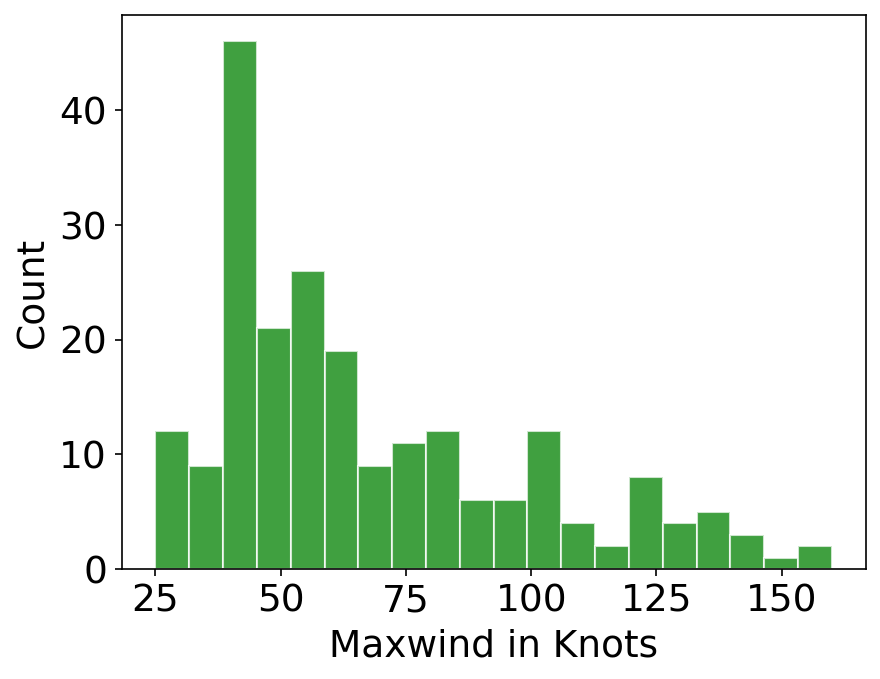

In [11]:
yearly_samples = np.array([int(a[-1]) for a in subj])
rep_ids = np.repeat(np.arange(len(yearly_samples)), yearly_samples)

maxwind = jax.ops.segment_max(jnp.asarray(seq[:, 5], dtype = np.float32), rep_ids, indices_are_sorted=True)

plt.figure(dpi=150)
plt.rc('font', size=18)
plt.hist(np.asarray(maxwind), 20, density=False, facecolor='g', edgecolor="w", alpha=0.75)
plt.xlabel('Maxwind in Knots')
plt.ylabel('Count')
plt.show()

To assess how well the tracks are represented by the splines, we plot a histogram of their $R^2$-values. The maximal value is 1, indicating a perfect fit.

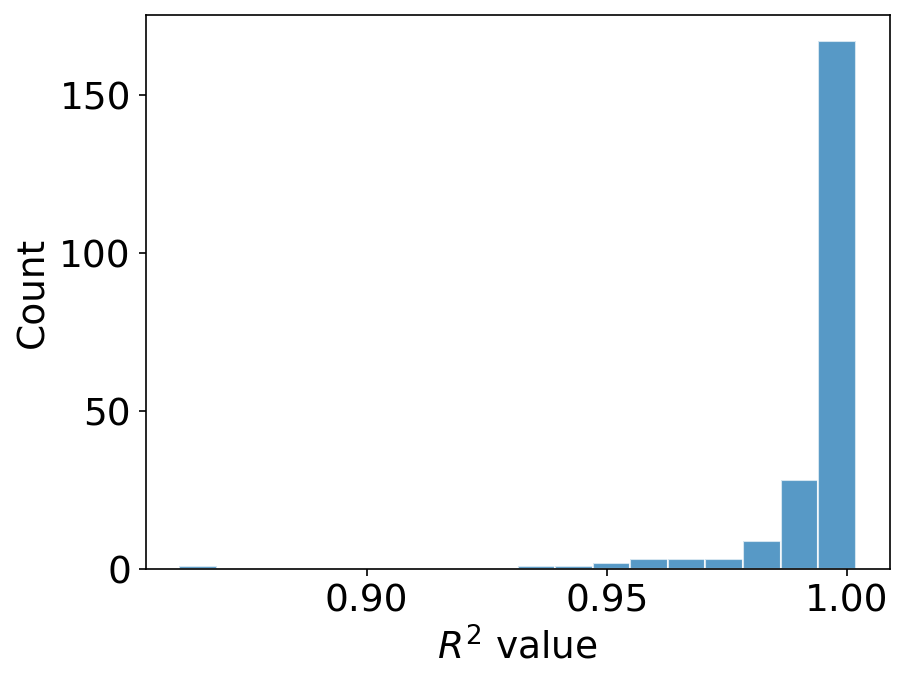

In [12]:
plt.figure(dpi=150)
plt.rc('font', size=18)
x = np.load('datasets/R2_2_segment_splines.npy')
_ = plt.hist(x, 18, density=False, edgecolor="w", alpha=0.75)

plt.xlabel('$R^2$ value')
plt.ylabel('Count')


plt.show()

We can also plot the original trend and the corresponding spline for all hurricanes.

/tmp/ipykernel_15919/4258983171.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_cat_gray = cm.get_cmap('gray')


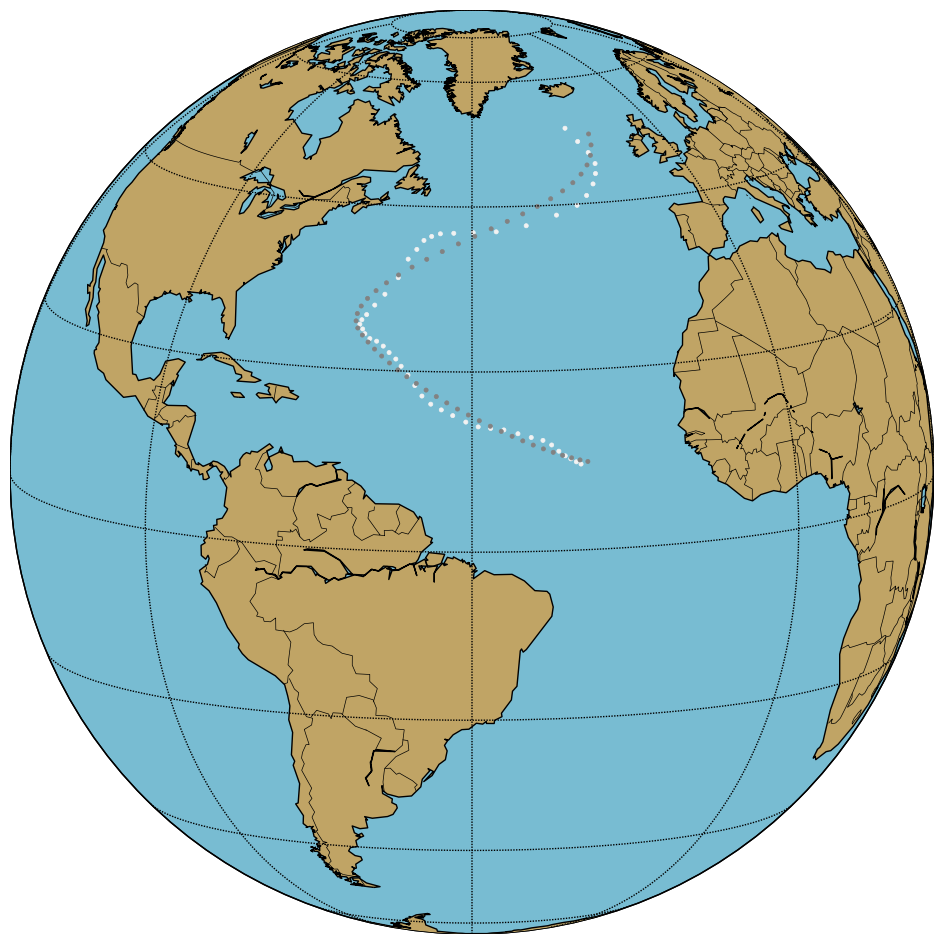

In [13]:
from matplotlib import cm
from util import sample_spline, visEarth
# instantiate manifolds again (the cell above might not have been run)
S2 = Sphere()
BfS2 = Bezierfold(S2, 2, degree)

def visualize_tracks(index):
    # spline approximations
    s_id = BfS2.from_coords(ctrl_pts[index])
    seq_spline = [sample_spline(s_id)]

    # original data
    seq_orig = [seq[ids[index]:ids[index] + subj[index, 2], 3:5]]

    cmap_cat_gray = cm.get_cmap('gray')
    visEarth([seq_orig, seq_spline], [[130], [70]], title=None, c_map=cmap_cat_gray)

visualize_tracks(5)  # replace by indices between 0 and 217 to see other hurricanes

In [14]:
from morphomatics.stats import PrincipalGeodesicAnalysis
import time

t = time.perf_counter()

# principal geodesic analysis
pga = PrincipalGeodesicAnalysis(BfS2, ctrl_pts)

print('computing PGA took %f seconds' % (time.perf_counter()-t))

lbl = np.array([colors[y[i]] for i in range(len(y))])
x = pga.coeffs
cen_0 = np.mean(x[np.where(y==0)[0]], axis=0)
cen_1 = np.mean(x[np.where(y==1)[0]], axis=0)
cen_2 = np.mean(x[np.where(y==2)[0]], axis=0)
centroids = np.array([cen_0, cen_1, cen_2])

plt.figure(dpi=150, figsize=(8,6))
ax = plt.subplot(111)
plt.rc('font', size=12)
plt.rc('axes', labelsize=16)
plt.scatter(*x.T[:2], c=lbl, cmap=cm.get_cmap('jet'))
lc = np.array([colors[i] for i in range(len(centroids))])
plt.scatter(*centroids.T[:2], c=lc, edgecolor='k', s=160, linewidths=3, cmap=cm.get_cmap('jet'))
plt.legend(handles=legend_handle)
ax.set(xlabel='$1^{st}$ principal mode', ylabel='$2^{nd}$ principal mode')
ax.yaxis.set_major_locator(plt.MaxNLocator(5))
plt.autoscale()
plt.show()

F_norm (0): 9.668245911598206e-05
F_norm (1): 0.01827077567577362
F_norm (2): 0.016439788043498993
F_norm (3): 0.014792189933359623
F_norm (4): 0.013309640809893608
F_norm (5): 0.011975685134530067
F_norm (6): 0.010775427334010601
F_norm (7): 0.009695501066744328
F_norm (8): 0.008723782375454903
F_norm (9): 0.007849478162825108
F_norm (10): 0.007062844000756741
F_norm (11): 0.006354939192533493
F_norm (12): 0.0057180654257535934
F_norm (0): 0.00010076910257339478
F_norm (1): 7.76834785938263e-05
F_norm (2): 0.0007801465690135956
F_norm (3): 0.003220701590180397
F_norm (4): 0.0019482262432575226
F_norm (5): 0.4057353138923645
F_norm (6): 0.3658519387245178
F_norm (7): 0.32976233959198
F_norm (8): 0.2971392869949341
F_norm (9): 0.2676747441291809
F_norm (10): 0.24108117818832397
F_norm (11): 0.21709229052066803
F_norm (12): 0.1954634189605713
F_norm (0): 0.00010363012552261353
F_norm (1): 5.665239334106445
F_norm (2): 4.476115703582764
F_norm (3): 4.194779396057129
F_norm (4): 4.36158990

NotImplementedError: This function has not been implemented yet.